In [1]:
import numpy as np
import matplotlib.pyplot as plt


def compute_ray_path(h, v, p):
    """
    Compute ray path coordinates for a given ray parameter.

    h : layer thicknesses (km)
    v : velocities (km/s)
    p : ray parameter (s/km)
    """

    x = []
    depth = np.cumsum([0] + h)

    # Determine layers the ray travels through
    for i in range(len(v)):

        if p * v[i] >= 1:
            break   # ray turns above this layer

        theta = np.arcsin(p * v[i])
        x_i = h[i] * np.tan(theta)

        x.append(x_i)

    # Build ray coordinates
    xd = [0]
    zd = [0]

    # Downward path
    for i in range(len(x)):
        xd.append(xd[-1] + x[i])
        zd.append(depth[i+1])

    # Upward path
    for i in reversed(range(len(x))):
        xd.append(xd[-1] + x[i])
        zd.append(depth[i])

    return xd, zd

def compute_TX(h, v, p):

    X = 0
    T = 0

    for i in range(len(v)):

        if p * v[i] >= 1:
            break

        theta = np.arcsin(p * v[i])

        # horizontal distance
        X += h[i] * np.tan(theta)

        # travel time
        T += h[i] / (v[i] * np.cos(theta))

    # multiply by 2 for down + up path
    X = 2 * X
    T = 2 * T

    return X, T

def plot_rays(h, v, p_values):

    depth = np.cumsum([0] + h)

    plt.figure(figsize=(6,6))

    for p in p_values:
        xd, zd = compute_ray_path(h, v, p)
        plt.plot(xd, zd, label=f"p = {p:.3f}")

        print(f"Ray parameter p = {p}")
        print(f"Total horizontal distance X = {xd[-1]} km")
        print()

    plt.plot(xd, zd, label=f"p = {p}")

    # Draw layer boundaries
    for d in depth:
        plt.axhline(d, linestyle='--', color='black')

    plt.gca().invert_yaxis()

    plt.xlabel("Distance (km)")
    plt.ylabel("Depth (km)")
    plt.title("Seismic Ray Paths")

    plt.legend()
    plt.grid(True)

    plt.show()

def plot_TX(h, v, p_values):

    X_list = []
    T_list = []

    plt.figure()

    for p in p_values:

        X, T = compute_TX(h, v, p)

        X_list.append(X)
        T_list.append(T)

        # print values in terminal
        print(f"p = {p:.3f}  ->  X = {X:.3f} km , T = {T:.3f} s")

        # plot point
        plt.scatter(X, T)

        # label point with p value
        plt.text(X, T, f"p={p:.3f}", fontsize=9)

    plt.plot(X_list, T_list)

    plt.xlabel("Distance X (km)")
    plt.ylabel("Travel Time T (s)")
    plt.title("Travel Time Curve (T vs X)")

    plt.grid(True)

    plt.show()

Ray parameter p = 0.15
Total horizontal distance X = 16.888449629010328 km



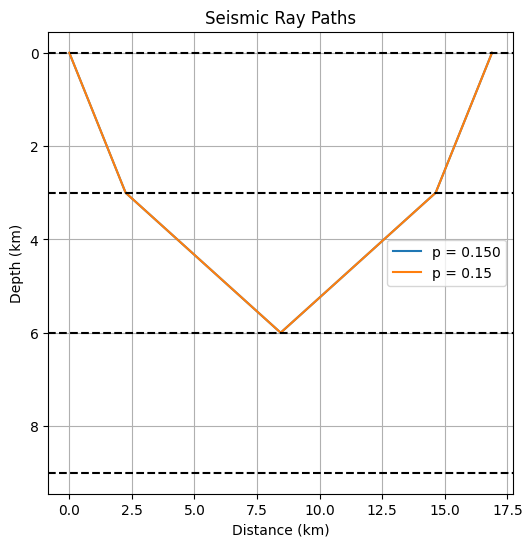

p = 0.150  ->  X = 16.888 km , T = 4.169 s


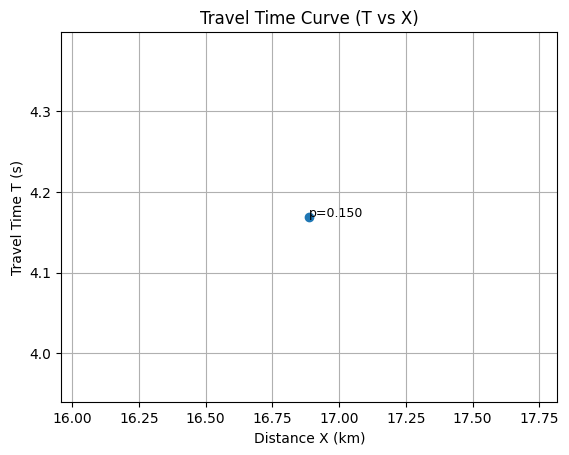

In [2]:
h = [3,3,3]      # layer thickness (km)
v = [4,6,8]          # velocity model (km/s)
# ray parameters
p_values = np.linspace(0.15, 0.15, 1)

plot_rays(h, v, p_values)
plot_TX(h, v, p_values)

Ray parameter p = 0.07
Total horizontal distance X = 10.923215993127732 km

Ray parameter p = 0.0925
Total horizontal distance X = 16.60947127937015 km

Ray parameter p = 0.115
Total horizontal distance X = 28.17722784832081 km

Ray parameter p = 0.1375
Total horizontal distance X = 43.212521907477885 km

Ray parameter p = 0.16
Total horizontal distance X = 16.38095238095238 km



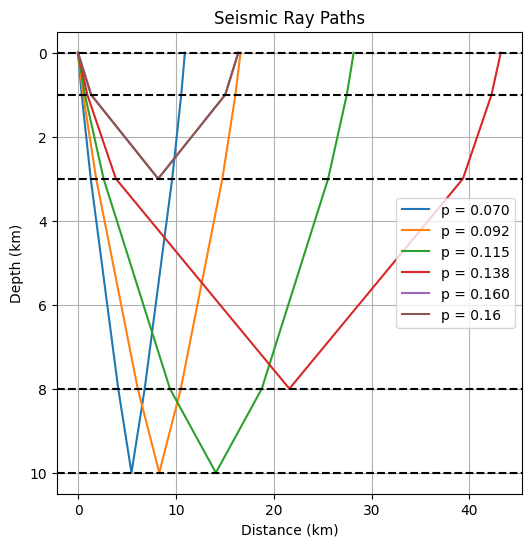

p = 0.070  ->  X = 10.923 km , T = 3.404 s
p = 0.092  ->  X = 16.609 km , T = 3.871 s
p = 0.115  ->  X = 28.177 km , T = 5.094 s
p = 0.138  ->  X = 43.213 km , T = 6.996 s
p = 0.160  ->  X = 16.381 km , T = 3.048 s


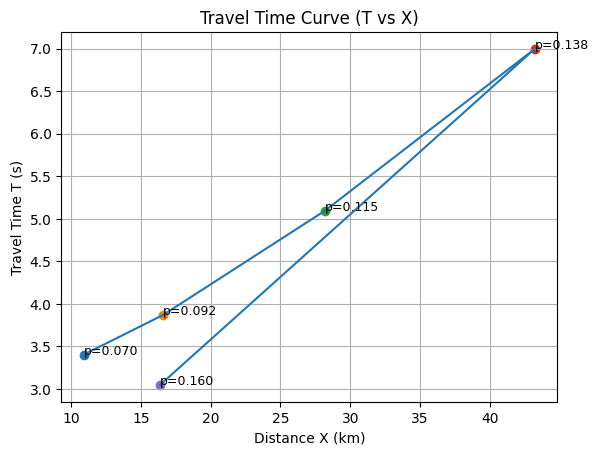

In [7]:
h = [1, 2, 5, 2]      # layer thickness (km)
v = [5, 6, 7, 8]          # velocity model (km/s)
# ray parameters
p_values = np.linspace(0.07, 0.16, 5)

plot_rays(h, v, p_values)
plot_TX(h, v, p_values)

Ray parameter p = 0.07
Total horizontal distance X = 8.218827361530531 km

Ray parameter p = 0.0925
Total horizontal distance X = 12.095466797462855 km

Ray parameter p = 0.115
Total horizontal distance X = 19.789126997127905 km

Ray parameter p = 0.1375
Total horizontal distance X = 14.318322474484539 km

Ray parameter p = 0.16
Total horizontal distance X = 24.710219681678037 km



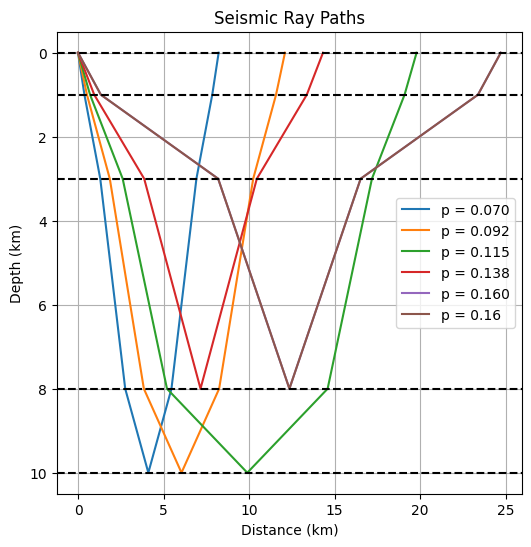

p = 0.070  ->  X = 8.219 km , T = 4.369 s
p = 0.092  ->  X = 12.095 km , T = 4.687 s
p = 0.115  ->  X = 19.789 km , T = 5.501 s
p = 0.138  ->  X = 14.318 km , T = 4.724 s
p = 0.160  ->  X = 24.710 km , T = 6.301 s


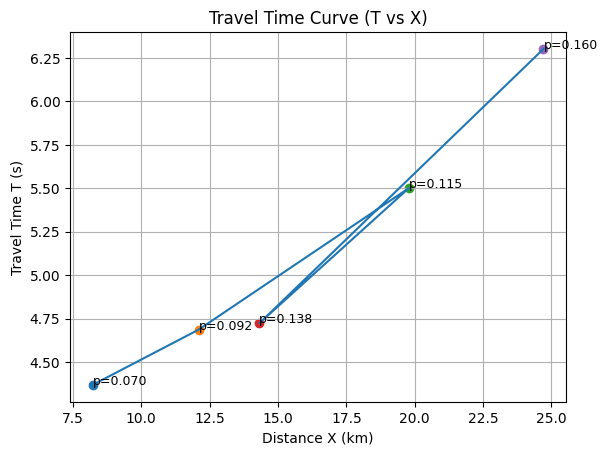

In [8]:
#  with LVZ

h = [1, 2, 5, 2]      # layer thickness (km)
v = [5, 6, 4, 8]          # velocity model (km/s)

# ray parameters
p_values = np.linspace(0.07, 0.16, 5)

plot_rays(h, v, p_values)
plot_TX(h, v, p_values)